In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression

## A. Visualising the Gumbel distributionzer

To help you get familiar with the Gumbel distribution, you can use: https://www.acsu.buffalo.edu/~adamcunn/probability/gumbel.html

### A.1 Generate skill acquisition distributions

In this model, the Gumbel distribution models imperfect imitation. Its two parameters control:

- loc (mu): how hard the skill is to acquire (lower = harder)
- scale (delta): how variable the errors are across imitators

In [2]:
np.random.seed(37)

n = 6000

simple  = np.random.gumbel(loc=-5, scale=3, size=n)
complex_ = np.random.gumbel(loc=-9, scale=2, size=n)

data = pd.DataFrame({
    "z": np.concatenate([simple, complex_]),
    "skill": np.repeat(["simple", "complex"], n)
})

### A.2 Plot the distributions

The vertical dashed line at z=0 marks the skill level of the cultural model (the demonstrator).

The area to the right of the line represents the probability of exceeding the demonstrator's skill, while the area to the left represent the probability of being worse that the demonstrator.

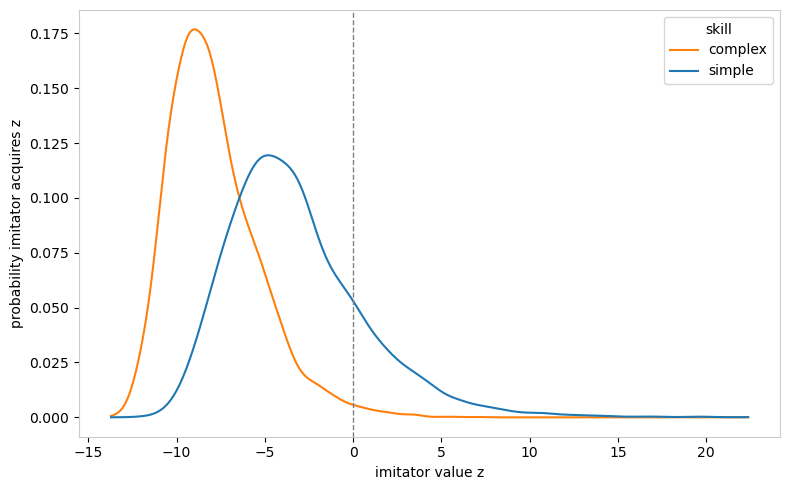

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = {"simple": "#1f77b4", "complex": "#ff7f0e"}

for skill, group in data.groupby("skill"):
    kde = gaussian_kde(group["z"])
    x = np.linspace(data["z"].min(), data["z"].max(), 500)
    ax.plot(x, kde(x), label=skill, color=colors[skill])

ax.axvline(x=0, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("imitator value z")
ax.set_ylabel("probability imitator acquires z")
ax.legend(title="skill")
ax.set_facecolor("white")
fig.patch.set_facecolor("white")
for spine in ax.spines.values():
    spine.set_edgecolor("#cccccc")

plt.tight_layout()
plt.show()

## B. Building the model

### B.1 Single simulation run

We begin with a population of N individuals, all initialised with skill level *z=1*.

At each timestep, every individual tries to imitate the best individual in the population (the one with largest *z*).

Imitation is imperfect: new skill values are drawn from a Gumbel distribution centred on *z.max() - alpha*.

We track *z_bar* (average skill level) and *z_delta_bar* (change in average skill level) over time.

In [4]:
# Set population size
N = 1000
# Set number of simulation rounds
t_max = 5000

# Initialise z: everyone starts with skill level 1
z = np.ones(N)

# Storage vectors
z_bar = np.empty(t_max)
z_delta_bar = np.empty(t_max)

# Parameters for Gumbel distribution
# sigma: variability of imitation errors
# alpha: difficulty of the skill (higher = harder)
sigma = 1
alpha = 7

for r in range(t_max):
    # Each individual imitates the best demonstrator with error
    # mu = z.max() - alpha shifts the distribution left: most imitators do worse than the model
    z_new = np.random.gumbel(loc=z.max() - alpha, scale=sigma, size=N)

    # Record average skill level
    z_bar[r] = z_new.mean()

    # Record average change in skill (positive = population is improving)
    z_delta_bar[r] = (z_new - z).mean()

    # Update z for the next round
    z = z_new

### B2. Plot change in average skill level over time

If the mean of *z_delta_bar* (dashed line) is above 0, the population is improving on average.

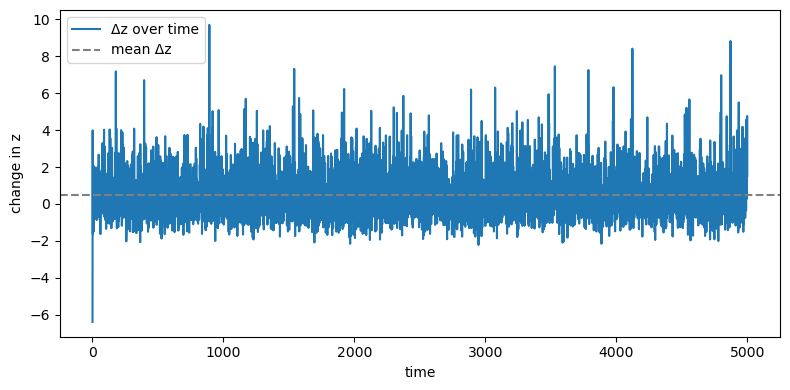

In [5]:
z_delta_bar_val = pd.DataFrame({
    "x": np.arange(1, len(z_delta_bar) + 1),
    "y": z_delta_bar
})

plt.figure(figsize=(8, 4))
plt.plot(z_delta_bar_val["x"], z_delta_bar_val["y"], label="Δz over time")

plt.axhline(
    y=z_delta_bar_val["y"].mean(),
    color="grey",
    linestyle="--",
    label="mean Δz"
)

plt.xlabel("time")
plt.ylabel("change in z")
plt.legend()
plt.tight_layout()
plt.show()

Here, we notice that *z_delta_bar*, or simply Δz plateaus around 0.5 (the grey dashed line). 

Because this line is above 0, on average the population will improve its skill over time. 

We will see that in B3.

### B3. Plot average skill level over time

If *Δz* is consistently positive, *z_bar* should increase without bound.

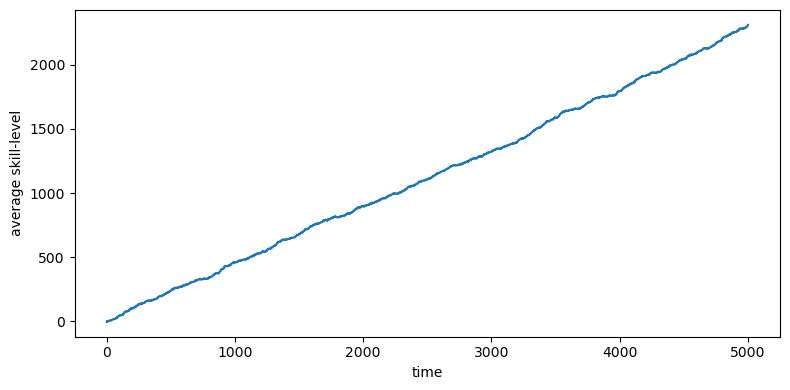

In [6]:
z_bar_val = pd.DataFrame({
    "x": np.arange(1, len(z_bar) + 1),
    "y": z_bar
})

plt.figure(figsize=(8, 4))
plt.plot(z_bar_val["x"], z_bar_val["y"], label="average skill-level")

plt.xlabel("time")
plt.ylabel("average skill-level")
plt.tight_layout()
plt.show()

## C. Running the model across population sizes

As always with modeling, we want to run multiple model with different parameters value to test their impact on the model.

### C1. Wrap the model in a reusable function

We average *z_delta_bar* across *R_MAX* independent runs to reduce noise.

A positive return value means the population can sustain or improve the skill at this *N*.

A negative value means the skill will erode over time.


In [ ]:
def demography_model(T_MAX, N, ALPHA, SIGMA, R_MAX):
    """
    Run the demography model and return the mean change in average skill level.

    Parameters:
    - T_MAX : number of timesteps per run
    - N     : population size (number of imitators)
    - ALPHA : skill difficulty — higher means harder to acquire
    - SIGMA : variability of imitation errors
    - R_MAX : number of independent runs to average over
    """
    results = []

    for _ in range(R_MAX):
        z = np.ones(N)
        z_delta_bar = np.empty(T_MAX)

        for t in range(T_MAX):
            # Imitate the best demonstrator with error
            demonstrator = z.max()
            z_new = np.random.gumbel(
                loc=demonstrator - ALPHA,
                scale=SIGMA,
                size=N
            )
            z_delta_bar[t] = (z_new - z).mean()
            z = z_new

        # Average change in skill level across all timesteps for this run
        results.append(z_delta_bar.mean())

    # Return the grand mean across all runs
    return np.mean(results)

### C2. Sweep over population sizes for simple and complex skills

We test two skills:
- simple: *alpha=7* —> easier to imitate, maintained at smaller *N*
- complex: *alpha=9* —> harder to imitate, requires larger *N* to maintain

In [8]:
sizes = np.concatenate(([2], np.arange(100, 6101, 500)))

simple_skill = [
    demography_model(T_MAX=200, N=N, ALPHA=7, SIGMA=1, R_MAX=20)
    for N in sizes
]

complex_skill = [
    demography_model(T_MAX=200, N=N, ALPHA=9, SIGMA=1, R_MAX=20)
    for N in sizes
]

# Interleave results: [simple[0], complex[0], simple[1], complex[1], ...]
z_delta_bar = np.ravel(np.column_stack([simple_skill, complex_skill]))

data = pd.DataFrame({
    "N": np.repeat(sizes, 2),
    "z_delta_bar": z_delta_bar,
    "skill": np.tile(["simple", "complex"], reps=len(sizes))
})

### C3 Plotting

The *x-axis* intercept (where *Δz = 0*) is the critical population size N*.

Skills with higher *alpha* cross zero at larger *N*, meaning they need bigger populations to survive.

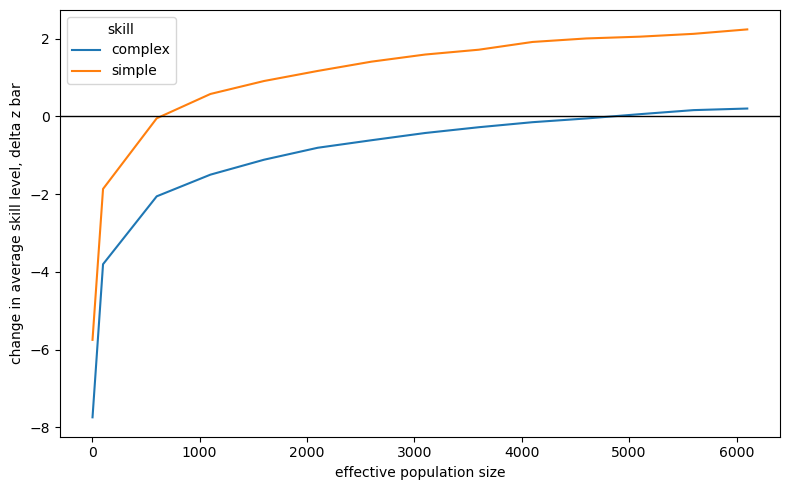

In [9]:
plt.figure(figsize=(8, 5))

for skill_type, df_sub in data.groupby("skill"):
    plt.plot(df_sub["N"], df_sub["z_delta_bar"], label=skill_type)

plt.axhline(y=0, color="black", linewidth=1)

plt.xlabel("effective population size")
plt.ylabel("change in average skill level, delta z bar")
plt.legend(title="skill")
plt.tight_layout()
plt.show()


Using a log scale makes the relationship approximately linear, which we exploit in section D.

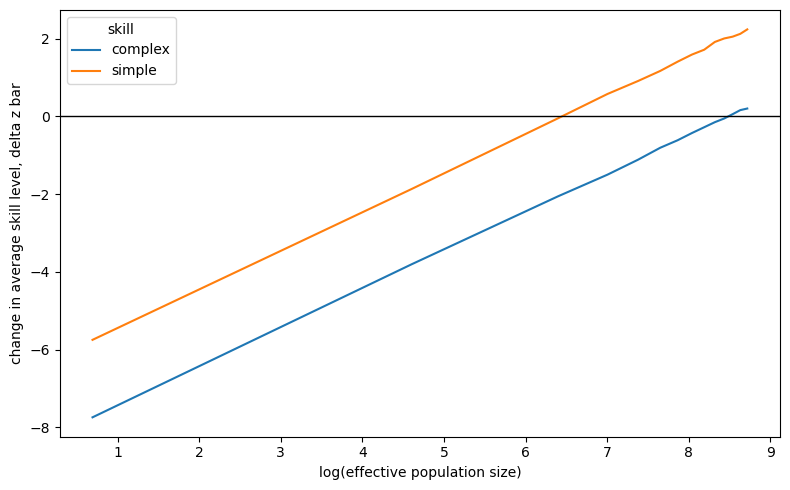

In [10]:
plt.figure(figsize=(8, 5))

for skill_type, df_sub in data.groupby("skill"):
    plt.plot(np.log(df_sub["N"]), df_sub["z_delta_bar"], label=skill_type)

plt.axhline(y=0, color="black", linewidth=1)

plt.xlabel("log(effective population size)")
plt.ylabel("change in average skill level, delta z bar")
plt.legend(title="skill")
plt.tight_layout()
plt.show()

## D. Calculating the critical population size N*

### D1. Analytic solution

Here, we use the analytical solution proposed by Henrich (sorry for the math).

Because the relationship between *log(N)* and *Δz* is approximately linear (see C.3 second plot), we can fit
*Δz = m * log(N) + b* and solve for N* analytically: *N\* = exp(-b / m)*.

Note that the value here are equivalent to the point where the line cross the x-axis in the first plot of C.3.

Simple skill:

In [11]:
# --- SIMPLE SKILL ---
df_simple = data[data["skill"] == "simple"]

X_simple = np.log(df_simple["N"]).values.reshape(-1, 1)
y_simple = df_simple["z_delta_bar"].values

model_simple = LinearRegression()
model_simple.fit(X_simple, y_simple)

b_simple = model_simple.intercept_
m_simple = model_simple.coef_[0]

# Solve Δz̄ = 0 → log(N*) = -b/m → N* = exp(-b/m)
N_star_simple = np.exp(-(b_simple / m_simple))
print("N* (simple): ", N_star_simple)

N* (simple):  635.1018988767515


Complex skill:

In [12]:
df_complex = data[data["skill"] == "complex"]

X_complex = np.log(df_complex["N"]).values.reshape(-1, 1)
y_complex = df_complex["z_delta_bar"].values

model_complex = LinearRegression()
model_complex.fit(X_complex, y_complex)

b_complex = model_complex.intercept_
m_complex = model_complex.coef_[0]

N_star_complex = np.exp(-(b_complex / m_complex))

print("N* (complex):", N_star_complex)

N* (complex): 4805.844426286556


### D2. Compute N* across a grid of skill complexities

We now vary both *N* and alpha systematically, giving us every *(N, alpha)* combination.

In [13]:
sizes = np.arange(100, 6101, 500)
alphas = np.arange(4, 9.5, 0.5)   # stop is exclusive, so go to 9.5

simulations = pd.DataFrame(
    [(N, a) for N in sizes for a in alphas],
    columns=["N", "alpha"]
)

simulations.head()

,N,alpha
0,100,4.0
1,100,4.5
2,100,5.0
3,100,5.5
4,100,6.0


### D3. Run the model for all (N, alpha) combinations

In [14]:
z_delta_bar = [
    demography_model(
        T_MAX=200,
        N=int(simulations.loc[i, "N"]),
        ALPHA=float(simulations.loc[i, "alpha"]),
        SIGMA=1,
        R_MAX=5
    )
    for i in range(len(simulations))
]

simulations["z_delta_bar"] = z_delta_bar

data = simulations

### D4. Fit one regression per alpha and extract N*

For each value of alpha, we fit the same log-linear regression as in D1
and record the *N\** where the skill is just barely maintained.

In [15]:
n_stars = []

for alpha in data["alpha"].unique():
    subset = data[data["alpha"] == alpha]

    X = np.log(subset["N"]).values.reshape(-1, 1)
    y = subset["z_delta_bar"].values

    model = LinearRegression()
    model.fit(X, y)

    b = model.intercept_
    m = model.coef_[0]

    n_star = np.exp(-(b / m))
    n_stars.append(n_star)

results = pd.DataFrame({
    "alpha": data["alpha"].unique(),
    "n_star": n_stars
})

### D5 Plotting

*N\** increases exponentially with alpha: very complex skills can only be maintained
by unrealistically large populations — unless learning itself improves (e.g. via teaching).

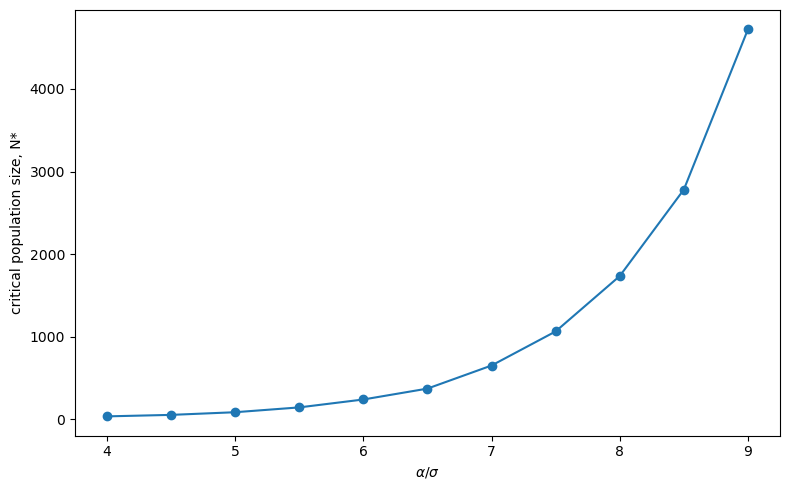

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(results["alpha"], results["n_star"], marker="o")

plt.xlabel(r"$\alpha / \sigma$")
plt.ylabel("critical population size, N*")

plt.tight_layout()
plt.show()

Notice how the critical population size increases exponentially with skill complexity.

This also suggests that very high skill levels are almost unreachable with a finite population sizes.

This effect could be lesses if we introduce different ways of learning (e.g. teaching) or modify the model.

# Correction

## Exercise 1 - Role of delta

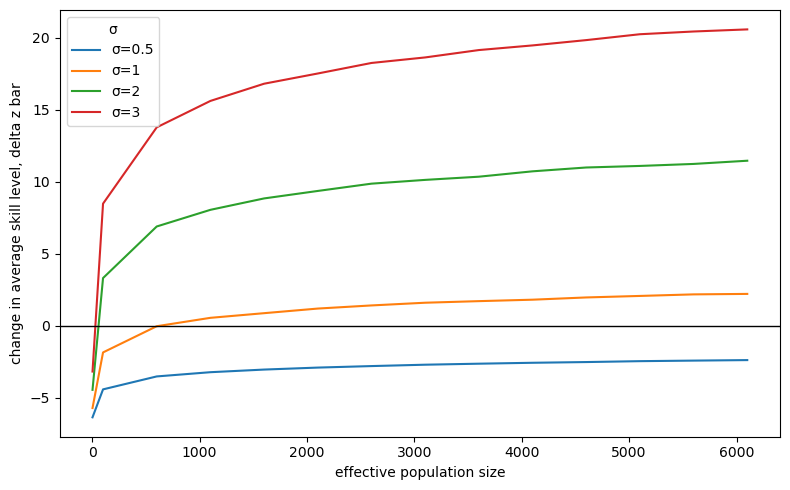

In [33]:
sizes = np.concatenate(([2], np.arange(100, 6101, 500)))
sigmas = [0.5, 1, 2, 3]

plt.figure(figsize=(8, 5))

for sigma in sigmas:
    results = [
        demography_model(T_MAX=200, N=N, ALPHA=7, SIGMA=sigma, R_MAX=20)
        for N in sizes
    ]
    plt.plot(sizes, results, label=f"σ={sigma}")

plt.axhline(y=0, color="black", linewidth=1)
plt.xlabel("effective population size")
plt.ylabel("change in average skill level, delta z bar")
plt.legend(title="σ")
plt.tight_layout()
plt.show()

## Exercise 2 - Population collapse

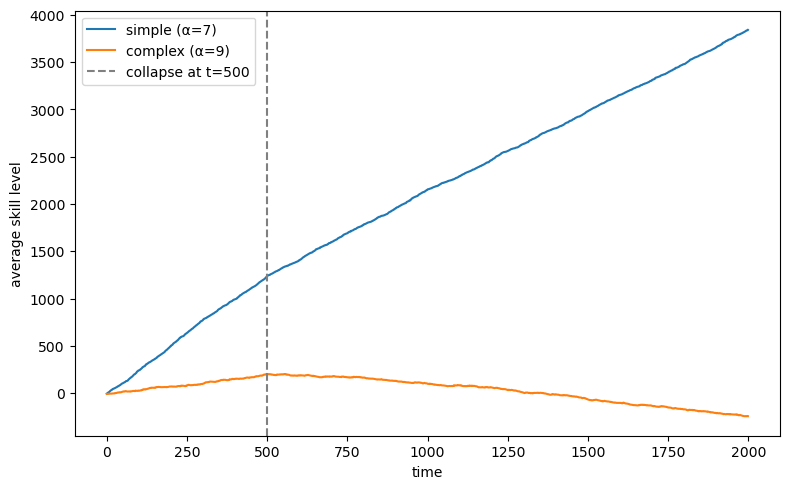

In [27]:
def demography_model_collapse(T_MAX, N, ALPHA, SIGMA, collapse_at=500):
    z = np.ones(N)
    z_bar = np.empty(T_MAX)

    for t in range(T_MAX):
        # Halve the population at the collapse timestep
        if t == collapse_at:
            z = np.random.choice(z, size=N // 2, replace=False)

        z_new = np.random.gumbel(
            loc=z.max() - ALPHA,
            scale=SIGMA,
            size=len(z)
        )
        z_bar[t] = z_new.mean()
        z = z_new

    return z_bar

z_bar_simple  = demography_model_collapse(T_MAX=2000, N=7000, ALPHA=7, SIGMA=1)
z_bar_complex = demography_model_collapse(T_MAX=2000, N=7000, ALPHA=9, SIGMA=1)

plt.figure(figsize=(8, 5))
plt.plot(z_bar_simple,  label="simple (α=7)")
plt.plot(z_bar_complex, label="complex (α=9)")
plt.axvline(x=500, color="grey", linestyle="--", label="collapse at t=500")
plt.xlabel("time")
plt.ylabel("average skill level")
plt.legend()
plt.tight_layout()
plt.show()

## Exercise 3 - Changing the distribution to a Gaussian

In [30]:
def demography_model_normal(T_MAX, N, ALPHA, SIGMA, R_MAX):
    results = []

    for _ in range(R_MAX):
        z = np.ones(N)
        z_delta_bar = np.empty(T_MAX)

        for t in range(T_MAX):
            z_new = np.random.normal(loc=z.max() - ALPHA, scale=SIGMA, size=N)
            z_delta_bar[t] = (z_new - z).mean()
            z = z_new

        results.append(z_delta_bar.mean())

    return np.mean(results)

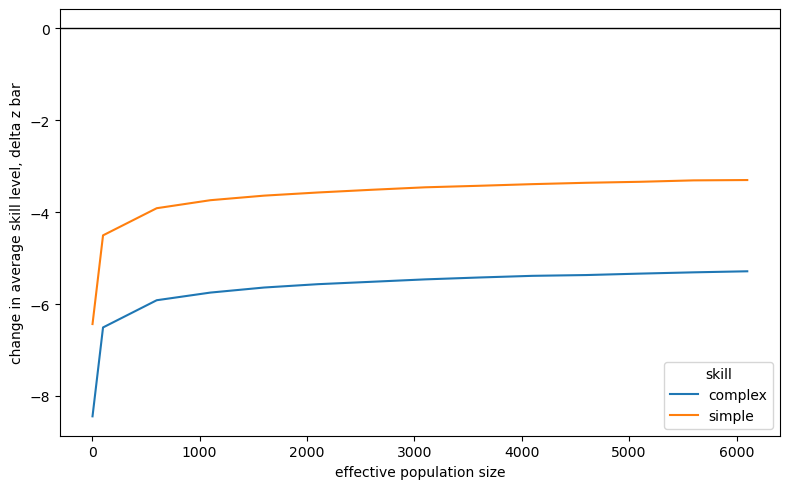

In [31]:
sizes = np.concatenate(([2], np.arange(100, 6101, 500)))

simple_skill = [
    demography_model_normal(T_MAX=200, N=N, ALPHA=7, SIGMA=1, R_MAX=20)
    for N in sizes
]

complex_skill = [
    demography_model_normal(T_MAX=200, N=N, ALPHA=9, SIGMA=1, R_MAX=20)
    for N in sizes
]

z_delta_bar = np.ravel(np.column_stack([simple_skill, complex_skill]))

data = pd.DataFrame({
    "N": np.repeat(sizes, 2),
    "z_delta_bar": z_delta_bar,
    "skill": np.tile(["simple", "complex"], reps=len(sizes))
})

plt.figure(figsize=(8, 5))

for skill_type, df_sub in data.groupby("skill"):
    plt.plot(df_sub["N"], df_sub["z_delta_bar"], label=skill_type)

plt.axhline(y=0, color="black", linewidth=1)
plt.xlabel("effective population size")
plt.ylabel("change in average skill level, delta z bar")
plt.legend(title="skill")
plt.tight_layout()
plt.show()